# S&P 500 — AI Exposure Analysis (Occupation & Company Level)

This notebook ranks **occupations** and **companies** in the S&P 500 workforce by their AI exposure, using two complementary scores:

| Score | Interpretation |
|-------|---------------|
| `time_based_score` | **Potential** exposure — how much of an occupation's work *could* be affected by AI (pi-weighted Eloundou β) |
| `observed_penetration_score` | **Observed** exposure — how much AI tool usage has actually been recorded for that occupation's tasks |

For each ranking we also show key workforce demographics: gender split, ethnicity breakdown, average seniority, education mix, and average salary — all drawn from `sp500_company_data.parquet`.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 35)

BASE       = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
OCC_FILE   = BASE / "Eloundou_New" / "occ_level_new.csv"
SP500_FILE = BASE / "data" / "sp500_company_data.parquet"

# ── Load occupation scores ─────────────────────────────────────────────
df_occ_raw = pd.read_csv(OCC_FILE, skipinitialspace=True)
df_occ_raw.columns = df_occ_raw.columns.str.strip()
df_occ_raw["O*NET-SOC Code"] = df_occ_raw["O*NET-SOC Code"].astype(str).str.strip()
df_occ_raw["Title"] = df_occ_raw["Title"].astype(str).str.strip()

# Isolate only the columns needed for the merge and deduplicate
SCORE_COLS = ["O*NET-SOC Code", "Title", "time_based_score", "observed_penetration_score"]
df_occ_scores = df_occ_raw[SCORE_COLS].drop_duplicates(subset=["O*NET-SOC Code"])
n_dupes = len(df_occ_raw) - len(df_occ_scores)
if n_dupes > 0:
    print(f"⚠ Removed {n_dupes} duplicate O*NET-SOC Code rows from score file")
assert df_occ_scores["O*NET-SOC Code"].is_unique, "O*NET-SOC Code must be unique for merge"

# ── Load SP500 workforce (only the columns we need) ───────────────────
COLS = ["onet_code", "seniority", "salary", "sex_predicted",
        "ethnicity_predicted", "highest_degree", "ticker", "company",
        "naics_code", "weight"]
df_sp = pq.read_table(SP500_FILE, columns=COLS).to_pandas()
df_sp["onet_code"] = df_sp["onet_code"].astype(str).str.strip()
df_sp = df_sp[df_sp["onet_code"].str.match(r"^\d{2}-")]
df_sp["weight"] = df_sp["weight"].fillna(1.0)

n_before = len(df_sp)

# ── Merge scores onto employee records (validated many-to-one) ─────────
df = df_sp.merge(
    df_occ_scores,
    left_on="onet_code", right_on="O*NET-SOC Code", how="left",
    validate="many_to_one",
).drop(columns=["O*NET-SOC Code"])

assert len(df) == n_before, "Merge must not duplicate employee rows"

# ── Diagnostics ────────────────────────────────────────────────────────
W = df["weight"]
w_total = W.sum()
w_tbs   = W[df["time_based_score"].notna()].sum()
w_ops   = W[df["observed_penetration_score"].notna()].sum()

print(f"Employee rows           : {len(df):,}")
print(f"Weighted employees      : {w_total:,.0f}")
print(f"With time_based_score   : {w_tbs:,.0f}  ({100*w_tbs/w_total:.1f}%)")
print(f"With penetration_score  : {w_ops:,.0f}  ({100*w_ops/w_total:.1f}%)")
print(f"Unique occupations      : {df['onet_code'].nunique():,}")
print(f"Unique companies        : {df['company'].nunique():,}")
print(f"Occ score merge         : ✓ many-to-one validated, 0 row duplication")

Employee rows           : 22,935,262
Weighted employees      : 26,493,389
With time_based_score   : 20,437,780  (77.1%)
With penetration_score  : 20,437,780  (77.1%)
Unique occupations      : 1,007
Unique companies        : 475
Occ score merge         : ✓ many-to-one validated, 0 row duplication


## 1 · Demographic helper

Reusable function that computes workforce demographics for any group of employee records.

In [3]:
def compute_demographics(group: pd.DataFrame) -> dict:
    """Return a flat dict of demographic stats for a group of employee rows.

    All counts and averages are weighted by the 'weight' column.
    """
    w = group["weight"].fillna(1.0)
    n = w.sum()

    # Gender (weighted)
    sex_mask = group["sex_predicted"].notna() & (group["sex_predicted"] != ".")
    w_sex = w[sex_mask]
    sex = group.loc[sex_mask, "sex_predicted"]
    w_sex_total = w_sex.sum()
    pct_female = 100 * w_sex[sex == "F"].sum() / w_sex_total if w_sex_total > 0 else np.nan

    # Ethnicity shares (weighted)
    eth_mask = group["ethnicity_predicted"].notna()
    w_eth = w[eth_mask]
    eth = group.loc[eth_mask, "ethnicity_predicted"]
    w_eth_total = w_eth.sum()
    eth_shares = {}
    for e in ["White", "Black", "Hispanic", "API", "Native", "Multiple"]:
        eth_shares[f"pct_{e.lower()}"] = 100 * w_eth[eth == e].sum() / w_eth_total if w_eth_total > 0 else np.nan

    # Seniority (weighted mean)
    sen_mask = group["seniority"].notna()
    w_sen = w[sen_mask]
    avg_seniority = np.average(group.loc[sen_mask, "seniority"], weights=w_sen) if w_sen.sum() > 0 else np.nan

    # Education (weighted)
    edu_mask = group["highest_degree"].notna()
    w_edu = w[edu_mask]
    edu = group.loc[edu_mask, "highest_degree"]
    w_edu_total = w_edu.sum()
    pct_bachelors_plus = (
        100 * w_edu[edu.isin(["Bachelor", "Master", "MBA", "Doctor"])].sum() / w_edu_total
        if w_edu_total > 0 else np.nan
    )

    # Salary (weighted mean)
    sal_mask = group["salary"].notna()
    w_sal = w[sal_mask]
    avg_salary = np.average(group.loc[sal_mask, "salary"], weights=w_sal) if w_sal.sum() > 0 else np.nan

    # n_employees kept as raw float — only round at display time
    return {
        "n_employees":        n,
        "pct_female":         round(pct_female, 1) if not np.isnan(pct_female) else np.nan,
        "avg_seniority":      round(avg_seniority, 2) if not np.isnan(avg_seniority) else np.nan,
        "avg_salary":         round(avg_salary, 0) if not np.isnan(avg_salary) else np.nan,
        "pct_bachelors_plus": round(pct_bachelors_plus, 1) if not np.isnan(pct_bachelors_plus) else np.nan,
        **{k: round(v, 1) if not np.isnan(v) else np.nan for k, v in eth_shares.items()},
    }

print("compute_demographics() defined — n_employees is raw weighted sum (not rounded)")

compute_demographics() defined — n_employees is raw weighted sum (not rounded)


## 2 · Top Occupations by AI Exposure

Ranked by `time_based_score` (potential) and `observed_penetration_score` (observed), with full demographic profiles.  Only occupations with at least 100 employees in the SP500 are shown.

In [4]:
TOP_N = 30
MIN_EMPLOYEES = 100

# ── Build occupation-level demographics + score coverage ───────────────
occ_records = []
for onet, grp in df.groupby("onet_code"):
    title = grp["Title"].iloc[0] if grp["Title"].notna().any() else onet
    tbs   = grp["time_based_score"].iloc[0]
    ops   = grp["observed_penetration_score"].iloc[0]
    demo  = compute_demographics(grp)
    w = grp["weight"]
    w_total = w.sum()
    demo["time_score_coverage"] = round(
        100 * w[grp["time_based_score"].notna()].sum() / w_total, 1
    ) if w_total > 0 else np.nan
    demo["observed_score_coverage"] = round(
        100 * w[grp["observed_penetration_score"].notna()].sum() / w_total, 1
    ) if w_total > 0 else np.nan
    occ_records.append({"onet_code": onet, "title": title,
                        "time_based_score": tbs,
                        "observed_penetration_score": ops,
                        **demo})

df_occ_demo = pd.DataFrame(occ_records)
df_occ_demo = df_occ_demo[df_occ_demo["n_employees"] >= MIN_EMPLOYEES]

print(f"Occupations with >= {MIN_EMPLOYEES} SP500 employees: {len(df_occ_demo)}")

# Display columns — round n_employees for readability
DISP_COLS = [
    "title", "n_employees", "time_based_score", "observed_penetration_score",
    "time_score_coverage", "observed_score_coverage",
    "avg_salary", "pct_female", "avg_seniority", "pct_bachelors_plus",
    "pct_white", "pct_black", "pct_hispanic", "pct_api",
]

# ── Table A: Top by potential exposure (time_based_score) ──────────────
df_top_theo = (
    df_occ_demo.dropna(subset=["time_based_score"])
    .sort_values("time_based_score", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)
df_top_theo.index += 1

print(f"\n{'='*100}")
print(f"  TOP {TOP_N} OCCUPATIONS BY POTENTIAL EXPOSURE (time_based_score)")
print(f"{'='*100}")
_disp = df_top_theo[DISP_COLS].copy()
_disp["n_employees"] = _disp["n_employees"].round(0).astype(int)
display(_disp)

Occupations with >= 100 SP500 employees: 936

  TOP 30 OCCUPATIONS BY POTENTIAL EXPOSURE (time_based_score)


,title,n_employees,time_based_score,observed_penetration_score,time_score_coverage,observed_score_coverage,avg_salary,pct_female,avg_seniority,pct_bachelors_plus,pct_white,pct_black,pct_hispanic,pct_api
1,Mathematicians,763,1.000,0.387,100.000,100.000,"84,512.000",26.800,3.380,97.900,49.100,4.900,6.900,38.200
2,Tax Preparers,46005,1.000,0.168,100.000,100.000,"93,571.000",51.000,3.400,96.300,56.100,6.400,13.300,22.800
3,Animal Scientists,171,0.984,0.000,100.000,100.000,"69,435.000",55.100,2.430,97.100,71.300,5.200,9.300,14.200
4,"Poets, Lyricists and Creative W...",9008,0.969,0.391,100.000,100.000,"33,987.000",34.000,2.130,91.800,42.700,7.000,8.300,40.800
5,Database Architects,155020,0.960,0.472,100.000,100.000,"107,481.000",24.900,3.830,98.500,40.700,5.700,6.100,46.600
6,Proofreaders and Copy Markers,3618,0.957,0.138,100.000,100.000,"31,626.000",48.500,2.020,94.800,37.000,6.000,8.800,47.900
7,Web Developers,111724,0.954,0.519,100.000,100.000,"78,625.000",29.200,2.400,96.700,41.500,7.400,7.300,42.900
8,Environmental Economists,1958,0.952,0.163,100.000,100.000,"99,476.000",36.600,3.280,98.100,58.300,7.800,10.000,23.300
9,Statisticians,19841,0.946,0.288,100.000,100.000,"60,780.000",43.200,2.490,98.500,37.100,5.000,7.400,50.200
10,Financial Quantitative Analysts,19229,0.929,0.479,100.000,100.000,"96,626.000",29.500,3.060,98.600,43.400,5.600,5.200,45.400


In [5]:
# ── Table B: Top by observed exposure (observed_penetration_score) ─────
df_top_obs = (
    df_occ_demo.dropna(subset=["observed_penetration_score"])
    .sort_values("observed_penetration_score", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)
df_top_obs.index += 1

print(f"\n{'='*100}")
print(f"  TOP {TOP_N} OCCUPATIONS BY OBSERVED EXPOSURE (observed_penetration_score)")
print(f"{'='*100}")
_disp = df_top_obs[DISP_COLS].copy()
_disp["n_employees"] = _disp["n_employees"].round(0).astype(int)
display(_disp)


  TOP 30 OCCUPATIONS BY OBSERVED EXPOSURE (observed_penetration_score)


,title,n_employees,time_based_score,observed_penetration_score,time_score_coverage,observed_score_coverage,avg_salary,pct_female,avg_seniority,pct_bachelors_plus,pct_white,pct_black,pct_hispanic,pct_api
1,Data Warehousing Specialists,108584,0.801,0.707,100.000,100.000,"70,241.000",32.000,3.070,97.400,37.800,5.300,7.700,48.400
2,Investment Fund Managers,262440,0.689,0.680,100.000,100.000,"122,458.000",32.500,3.830,98.200,53.600,5.500,6.400,34.100
3,Computer Programmers,84395,0.898,0.633,100.000,100.000,"40,228.000",27.500,1.740,97.300,26.700,3.600,4.500,64.700
4,Business Intelligence Analysts,539746,0.680,0.615,100.000,100.000,"72,521.000",41.900,2.780,96.800,44.500,6.300,9.500,39.100
5,Information Security Analysts,62573,0.630,0.567,100.000,100.000,"87,445.000",30.500,2.990,94.600,53.700,9.700,9.200,26.900
6,Search Marketing Strategists,63587,0.834,0.549,100.000,100.000,"66,469.000",44.200,3.220,95.500,49.400,6.400,9.800,33.700
7,Bioinformatics Technicians,1066,0.928,0.542,100.000,100.000,"76,428.000",49.100,2.640,96.600,60.400,5.700,7.900,24.800
8,Web Developers,111724,0.954,0.519,100.000,100.000,"78,625.000",29.200,2.400,96.700,41.500,7.400,7.300,42.900
9,Market Research Analysts and Ma...,71305,0.831,0.513,100.000,100.000,"80,392.000",52.400,2.980,97.200,53.900,6.000,11.500,27.600
10,Statistical Assistants,6095,0.791,0.486,100.000,100.000,"106,970.000",40.200,2.590,98.200,63.000,5.100,5.300,26.100


## 3 · Top Companies by AI Exposure

For each company we compute the **employee-weighted average** of `time_based_score` and `observed_penetration_score` across all its occupations, plus the same demographic profile.

**How the company score is calculated:** Every employee row in the parquet carries their occupation's score. The company score is simply `mean(score)` across all that company's employee rows. Because occupations with more workers at the company contribute more rows, this is an **employee-weighted average by construction** — large occupations pull the company mean proportionally to their headcount.

In [6]:
comp_records = []
for (ticker, company), grp in df.groupby(["ticker", "company"]):
    w = grp["weight"].fillna(1.0)

    # True employee-weighted average using weight column
    def emp_wavg(col):
        mask = grp[col].notna()
        if mask.sum() == 0:
            return np.nan
        return np.average(grp.loc[mask, col], weights=w[mask])

    demo = compute_demographics(grp)
    w_total = w.sum()
    demo["time_score_coverage"] = round(
        100 * w[grp["time_based_score"].notna()].sum() / w_total, 1
    ) if w_total > 0 else np.nan
    demo["observed_score_coverage"] = round(
        100 * w[grp["observed_penetration_score"].notna()].sum() / w_total, 1
    ) if w_total > 0 else np.nan

    comp_records.append({
        "ticker":   ticker,
        "company":  company,
        "time_based_score":            emp_wavg("time_based_score"),
        "observed_penetration_score":  emp_wavg("observed_penetration_score"),
        **demo,
    })

df_comp = pd.DataFrame(comp_records)
print(f"Companies: {len(df_comp)}")

# Display columns for company tables
COMP_DISP = [
    "ticker", "company", "n_employees", "time_based_score",
    "observed_penetration_score", "time_score_coverage", "observed_score_coverage",
    "avg_salary", "pct_female", "avg_seniority", "pct_bachelors_plus",
    "pct_white", "pct_black", "pct_hispanic", "pct_api",
]

# ── Table C: Top companies by potential exposure ───────────────────────
df_comp_theo = (
    df_comp.dropna(subset=["time_based_score"])
    .sort_values("time_based_score", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)
df_comp_theo.index += 1

print(f"\n{'='*100}")
print(f"  TOP {TOP_N} COMPANIES BY POTENTIAL EXPOSURE (time_based_score)")
print(f"{'='*100}")
_disp = df_comp_theo[COMP_DISP].copy()
_disp["n_employees"] = _disp["n_employees"].round(0).astype(int)
display(_disp)

Companies: 475

  TOP 30 COMPANIES BY POTENTIAL EXPOSURE (time_based_score)


,ticker,company,n_employees,time_based_score,observed_penetration_score,time_score_coverage,observed_score_coverage,avg_salary,pct_female,avg_seniority,pct_bachelors_plus,pct_white,pct_black,pct_hispanic,pct_api
1,EPAM,"EPAM Systems, Inc.",98026,0.773,0.287,91.500,91.500,"49,759.000",28.000,3.240,97.900,66.200,1.300,11.000,21.300
2,FDS,"FactSet Research Systems, Inc.",15955,0.766,0.291,76.900,76.900,"49,995.000",32.400,2.760,99.000,28.700,2.400,8.200,60.400
3,INTU,"Intuit, Inc.",31141,0.754,0.254,79.500,79.500,"107,438.000",44.600,3.130,94.400,49.500,7.900,8.100,33.800
4,ANET,"Arista Networks, Inc.",6601,0.733,0.230,88.400,88.400,"99,712.000",17.000,2.970,98.100,41.500,2.200,4.800,51.100
5,DDOG,"Datadog, Inc.",9793,0.730,0.258,66.400,66.400,"130,276.000",30.900,3.210,96.500,64.200,4.700,8.400,21.900
6,PLTR,"Palantir Technologies, Inc.",5964,0.717,0.253,76.600,76.600,"153,528.000",26.900,3.340,98.200,68.000,6.400,5.100,19.900
7,CTSH,Cognizant Technology Solutions ...,553323,0.711,0.311,84.600,84.600,"28,349.000",25.900,2.640,98.500,13.500,1.900,2.300,82.000
8,COIN,"Coinbase Global, Inc.",10998,0.710,0.303,77.400,77.400,"104,216.000",33.100,2.980,95.700,51.300,7.300,9.000,31.400
9,NVDA,NVIDIA Corp.,58298,0.708,0.215,80.500,80.500,"132,078.000",21.800,3.270,98.600,41.900,3.000,4.200,50.400
10,NOW,"ServiceNow, Inc.",38444,0.708,0.269,78.200,78.200,"106,234.000",32.500,3.760,97.700,47.700,4.300,5.900,41.600


In [7]:
# ── Table D: Top companies by observed exposure ───────────────────────
df_comp_obs = (
    df_comp.dropna(subset=["observed_penetration_score"])
    .sort_values("observed_penetration_score", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)
df_comp_obs.index += 1

print(f"\n{'='*100}")
print(f"  TOP {TOP_N} COMPANIES BY OBSERVED EXPOSURE (observed_penetration_score)")
print(f"{'='*100}")
_disp = df_comp_obs[COMP_DISP].copy()
_disp["n_employees"] = _disp["n_employees"].round(0).astype(int)
display(_disp)


  TOP 30 COMPANIES BY OBSERVED EXPOSURE (observed_penetration_score)


,ticker,company,n_employees,time_based_score,observed_penetration_score,time_score_coverage,observed_score_coverage,avg_salary,pct_female,avg_seniority,pct_bachelors_plus,pct_white,pct_black,pct_hispanic,pct_api
1,HOOD,"Robinhood Markets, Inc.",1163,0.647,0.363,80.300,80.300,"73,875.000",43.300,3.490,92.800,72.300,5.300,9.600,12.700
2,MSCI,"MSCI, Inc.",9462,0.651,0.338,82.000,82.000,"62,574.000",33.100,3.000,98.800,33.800,3.700,13.100,49.200
3,BLK,"BlackRock, Inc.",44391,0.619,0.338,80.900,80.900,"99,940.000",38.200,3.260,97.900,55.000,4.800,6.400,33.500
4,NTRS,Northern Trust Corp.,34406,0.639,0.337,64.100,64.100,"82,746.000",38.300,3.190,98.300,42.100,5.600,5.700,46.200
5,STT,State Street Corp.,65499,0.597,0.331,76.000,76.000,"70,777.000",34.000,2.890,98.500,43.400,2.900,2.200,51.200
6,RJF,"Raymond James Financial, Inc.",24799,0.606,0.329,81.900,81.900,"109,046.000",38.700,3.130,94.500,80.600,8.900,5.200,5.000
7,MS,Morgan Stanley,129746,0.629,0.328,80.100,80.100,"112,574.000",35.600,3.310,97.600,55.300,6.400,5.900,32.000
8,TROW,"T. Rowe Price Group, Inc.",10981,0.654,0.327,77.900,77.900,"117,030.000",41.200,3.130,96.500,66.800,14.800,3.900,14.000
9,GS,"The Goldman Sachs Group, Inc.",94059,0.619,0.326,75.500,75.500,"110,912.000",38.600,3.080,97.800,46.900,6.500,6.000,40.100
10,SCHW,The Charles Schwab Corp.,43604,0.639,0.315,79.300,79.300,"110,554.000",35.400,3.230,94.700,68.900,7.700,10.300,12.700


## 3b · All Companies by Size (largest to smallest)

Full table of all SP500 companies ranked by employee count, with both exposure scores and demographics.

In [8]:
df_comp_by_size = (
    df_comp
    .sort_values("n_employees", ascending=False)
    .reset_index(drop=True)
)
df_comp_by_size.index += 1

print(f"All {len(df_comp_by_size)} companies, largest to smallest:\n")
_disp = df_comp_by_size[COMP_DISP].copy()
_disp["n_employees"] = _disp["n_employees"].round(0).astype(int)
display(_disp)

All 475 companies, largest to smallest:



,ticker,company,n_employees,time_based_score,observed_penetration_score,time_score_coverage,observed_score_coverage,avg_salary,pct_female,avg_seniority,pct_bachelors_plus,pct_white,pct_black,pct_hispanic,pct_api
1,AMZN,"Amazon.com, Inc.",1174867,0.576,0.184,77.300,77.300,"64,929.000",32.800,2.580,90.900,42.000,8.100,9.300,40.000
2,WMT,"Walmart, Inc.",565391,0.339,0.102,80.700,80.700,"49,162.000",51.900,1.840,75.200,55.800,13.100,18.400,12.000
3,CTSH,Cognizant Technology Solutions ...,553323,0.711,0.311,84.600,84.600,"28,349.000",25.900,2.640,98.500,13.500,1.900,2.300,82.000
4,IBM,International Business Machines...,536764,0.688,0.268,85.900,85.900,"62,147.000",29.400,3.340,96.900,39.700,3.200,8.500,47.800
5,MSFT,Microsoft Corp.,513268,0.663,0.235,80.000,80.000,"89,589.000",30.500,3.010,95.200,45.600,6.700,7.400,39.700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,HOOD,"Robinhood Markets, Inc.",1163,0.647,0.363,80.300,80.300,"73,875.000",43.300,3.490,92.800,72.300,5.300,9.600,12.700
472,ARE,Alexandria Real Estate Equities...,782,0.476,0.149,85.900,85.900,"132,882.000",42.000,3.590,96.200,60.000,6.000,12.400,20.800
473,FRT,Federal Realty Investment Trust,681,0.436,0.118,84.800,84.800,"99,568.000",48.900,2.830,93.700,70.500,11.500,11.900,5.800
474,TPL,Texas Pacific Land Corp.,114,0.515,0.161,85.500,85.500,"99,164.000",36.900,3.140,95.400,71.300,12.400,13.500,2.800


## 4 · Figures

In [9]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ── NAICS 2-digit sector labels ────────────────────────────────────────
NAICS_SECTORS = {
    "11": "Agriculture", "21": "Mining & Oil/Gas", "22": "Utilities",
    "23": "Construction", "31": "Manufacturing", "32": "Manufacturing",
    "33": "Manufacturing", "42": "Wholesale Trade",
    "44": "Retail Trade", "45": "Retail Trade",
    "48": "Transportation", "49": "Transportation",
    "51": "Information & Tech", "52": "Finance & Insurance",
    "53": "Real Estate", "54": "Professional Services",
    "55": "Mgmt of Companies", "56": "Admin & Support",
    "61": "Education", "62": "Healthcare",
    "71": "Arts & Entertainment", "72": "Accommodation & Food",
    "81": "Other Services", "92": "Public Admin",
}

# NAICS per company: use most common non-null value (mode) per ticker
_naics_rows = df.dropna(subset=["ticker", "naics_code"])[["ticker", "naics_code"]]
naics_per_company = (
    _naics_rows.groupby("ticker")["naics_code"]
    .agg(lambda s: s.mode().iloc[0] if len(s.mode()) > 0 else np.nan)
    .reset_index()
)
naics_per_company = naics_per_company.dropna(subset=["naics_code"])
naics_per_company["naics2"] = naics_per_company["naics_code"].astype(str).str[:2]
naics_per_company["sector"] = naics_per_company["naics2"].map(NAICS_SECTORS).fillna("Other")

df_comp_plot = df_comp.merge(
    naics_per_company[["ticker", "naics2", "sector"]],
    on="ticker", how="left"
)
df_comp_plot["sector"] = df_comp_plot["sector"].fillna("Other")

print(f"Companies with NAICS sector: {df_comp_plot['sector'].notna().sum()}")
print(f"Unique sectors: {df_comp_plot['sector'].nunique()}")
print("NAICS rule: most common (mode) non-null naics_code per ticker")
print(df_comp_plot["sector"].value_counts())

Companies with NAICS sector: 475
Unique sectors: 17
NAICS rule: most common (mode) non-null naics_code per ticker
sector
Manufacturing            171
Finance & Insurance       69
Information & Tech        51
Real Estate               32
Utilities                 31
Retail Trade              23
Transportation            21
Mining & Oil/Gas          18
Professional Services     12
Accommodation & Food      11
Admin & Support            9
Wholesale Trade            9
Construction               8
Healthcare                 6
Agriculture                2
Other Services             1
Arts & Entertainment       1
Name: count, dtype: int64


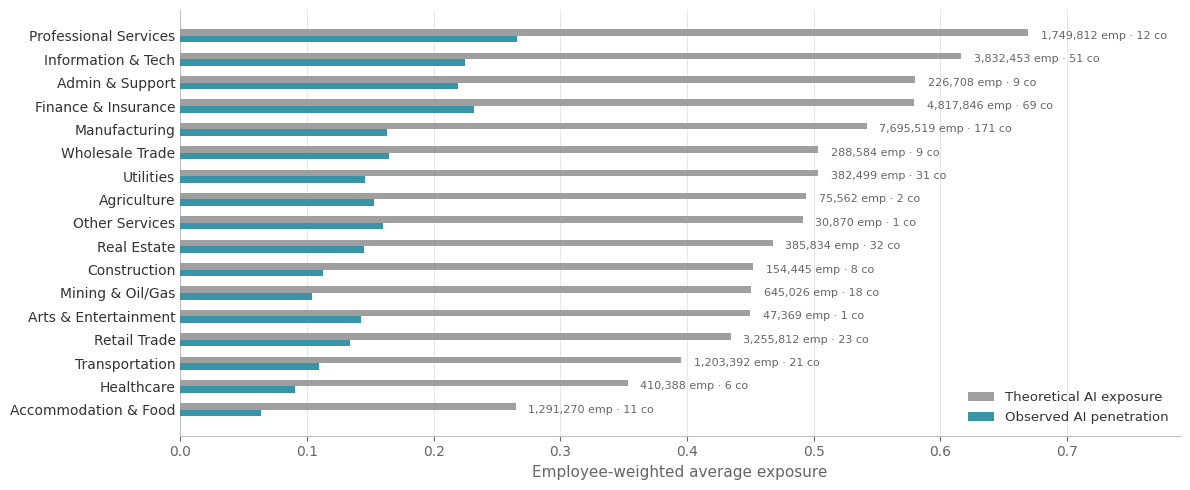

Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/industry_exposure_by_naics_nobg.png


In [13]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — Industry Exposure: employee-weighted avg by NAICS sector
# ══════════════════════════════════════════════════════════════════════

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPORT_DIR = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images")
REPORT_DIR.mkdir(exist_ok=True)

# Aggregate to sector level using raw weighted n_employees as weights
sector_records = []
for sector, grp in df_comp_plot.groupby("sector"):
    def wavg(col):
        valid = grp[[col, "n_employees"]].dropna(subset=[col])
        return (
            (valid[col] * valid["n_employees"]).sum() / valid["n_employees"].sum()
            if valid["n_employees"].sum() > 0 else np.nan
        )

    sector_records.append({
        "sector": sector,
        "time_based_score": wavg("time_based_score"),
        "observed_penetration_score": wavg("observed_penetration_score"),
        "n_employees": grp["n_employees"].sum(),
        "n_companies": len(grp),
    })

df_sector = pd.DataFrame(sector_records).sort_values("time_based_score", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")
ax.patch.set_alpha(0.0)

y = np.arange(len(df_sector))
h = 0.28  # tighter grouping

# colorway from reference images
LONG_COLOR = "#9A9A9A"
SHORT_COLOR = "#2F8FA3"
TEXT_GRAY = "#666666"
AXIS_GRAY = "#BFBFBF"
GRID_GRAY = "#DDDDDD"

bars_theo = ax.barh(
    y + h / 2,
    df_sector["time_based_score"],
    h,
    color=LONG_COLOR,
    alpha=0.95,
    label="Theoretical AI exposure",
    zorder=3
)

bars_obs = ax.barh(
    y - h / 2,
    df_sector["observed_penetration_score"].fillna(0),
    h,
    color=SHORT_COLOR,
    alpha=0.95,
    label="Observed AI penetration",
    zorder=3
)

ax.set_yticks(y)
ax.set_yticklabels(df_sector["sector"], fontsize=10, color="#333333")
ax.set_xlabel("Employee-weighted average exposure", fontsize=11, color=TEXT_GRAY)

# x-axis ticks and labels in gray
ax.tick_params(axis="x", labelsize=10, colors=TEXT_GRAY)
ax.tick_params(axis="y", length=0)

# Employee count annotations
for i, row in enumerate(df_sector.itertuples()):
    obs_val = row.observed_penetration_score if not np.isnan(row.observed_penetration_score) else 0
    ax.text(
        max(row.time_based_score, obs_val) + 0.01,
        i,
        f"{row.n_employees:,.0f} emp · {row.n_companies} co",
        va="center",
        fontsize=8,
        color=TEXT_GRAY
    )

ax.set_xlim(0, df_sector["time_based_score"].max() + 0.12)
ax.xaxis.grid(True, color=GRID_GRAY, lw=0.5, zorder=0)
ax.set_axisbelow(True)

for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
ax.spines["left"].set_color(AXIS_GRAY)
ax.spines["bottom"].set_color(AXIS_GRAY)

ax.legend(
    loc="lower right",
    fontsize=9.5,
    frameon=False,
    labelcolor="#333333"
)

plt.tight_layout()

out_png = REPORT_DIR / "industry_exposure_by_naics_nobg.png"
plt.savefig(out_png, dpi=180, bbox_inches="tight", transparent=True)

plt.show()
print(f"Figure saved: {out_png}")

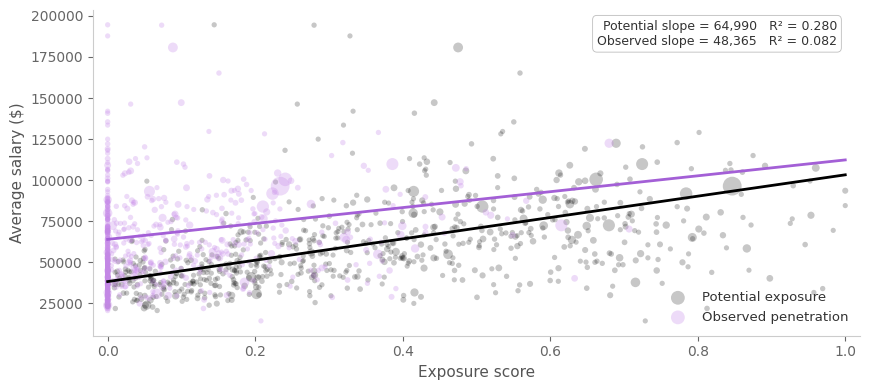

Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/salary_vs_exposure_overlay_nobg.png


In [16]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE 2 — Salary vs. Exposure (overlayed WLS, weighted by n_employees)
# ══════════════════════════════════════════════════════════════════════

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

REPORT_DIR = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images")
REPORT_DIR.mkdir(exist_ok=True)

OUT_PNG = REPORT_DIR / "salary_vs_exposure_overlay_nobg.png"

df_occ_plot = df_occ_demo.dropna(subset=["avg_salary"]).copy()

fig, ax = plt.subplots(figsize=(8.8, 4))
fig.patch.set_alpha(0)
ax.set_facecolor("none")
ax.patch.set_alpha(0.0)

# Colors
THEO_DOT  = "#000000"
OBS_DOT   = "#C68AE8"
THEO_LINE = "#000000"
OBS_LINE  = "#A35FD6"

def _plot_overlay(ax, d, xcol, dot_color, line_color, label, alpha_pts=0.28):
    d = d.dropna(subset=[xcol, "avg_salary", "n_employees"]).copy()

    n_emp = d["n_employees"]
    n_min, n_max = n_emp.min(), n_emp.max()
    sz = 14 + 170 * (n_emp - n_min) / max(n_max - n_min, 1)

    ax.scatter(
        d[xcol],
        d["avg_salary"],
        s=sz,
        color=dot_color,
        alpha=alpha_pts,
        edgecolors="none",
        zorder=2,
        label=label
    )

    X = sm.add_constant(d[xcol])
    fit = sm.WLS(d["avg_salary"], X, weights=d["n_employees"]).fit()
    slope = fit.params.iloc[1]
    intercept = fit.params.iloc[0]

    # force both fitted lines to span the full 0–1 exposure axis
    xline = np.linspace(0, 1, 200)
    yline = slope * xline + intercept
    ax.plot(
        xline,
        yline,
        color=line_color,
        lw=2.0,
        ls="-",
        zorder=4
    )

    return fit

fit_theo = _plot_overlay(
    ax, df_occ_plot, "time_based_score",
    THEO_DOT, THEO_LINE,
    "Potential exposure",
    alpha_pts=0.22
)

fit_obs = _plot_overlay(
    ax, df_occ_plot, "observed_penetration_score",
    OBS_DOT, OBS_LINE,
    "Observed penetration",
    alpha_pts=0.30
)

stat_text = (
    f"Potential slope = {fit_theo.params.iloc[1]:,.0f}   R² = {fit_theo.rsquared:.3f}\n"
    f"Observed slope = {fit_obs.params.iloc[1]:,.0f}   R² = {fit_obs.rsquared:.3f}"
)

ax.text(
    0.97, 0.97,
    stat_text,
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    ha="right",
    color="#333333",
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="#BBBBBB",
        lw=0.6,
        alpha=0.95
    )
)

ax.set_xlabel("Exposure score", fontsize=11, color="#555555")
ax.set_ylabel("Average salary ($)", fontsize=11, color="#555555")

# no grid
ax.set_axisbelow(True)

for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="both", labelsize=10, colors="#666666")

ax.set_xlim(-0.02, 1.02)

ax.legend(
    loc="lower right",
    fontsize=9.5,
    frameon=False,
    labelcolor="#333333"
)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=180, bbox_inches="tight", transparent=True)
plt.show()
print(f"Figure saved: {OUT_PNG}")